# **Clusterização espaço-temporal e dinâmica de eventos sísmicos**

## **1. Imports**

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.pipeline import Pipeline

# Transforma o diretório src em um módulo importável
ROOT = Path().resolve().parent
sys.path.append(str(ROOT)) 

In [2]:
from src.data_ingestion.io_usgs         import build_catalog, save_catalog_parquet, load_catalog_parquet, USGCQuery
from src.window_features.schemas import WindowConfig
from src.window_features.builder import build_features_df
from src.pca_pipeline.prepare import prepare_X
from src.pca_pipeline.pca_utils import fit_pca_full, fit_pca, pca_loadings
from src.pca_pipeline.plots import plot_explained_variance, plot_cumulative_variance
from sklearn.cluster import KMeans
from src.clustering.plots import plot_inertia_silhouette_vs_k, plot_clusters_pca
from src.clustering.metrics import silhouette_by_cluster
from src.spatial_validation.distance import add_plate_distance_column, summarize_plate_distance_by_cluster, plot_distance_boxplot



## **2. Importação de dados sísmicos**

In [3]:
# # ---------- Extração dos Dados ----------- #
# query_4p5_3y = USGCQuery(minmag=4.5)

# # Import dados de 3 anos
# df_4p5 = build_catalog(
#     years_back=3,
#     query=query_4p5_3y,
# )

path_4p5 = Path.cwd().parent / "data" / "raw" / "usgs_3y_minmag4p5.parquet"
# save_catalog_parquet(df=df_4p5, path=path_4p5)

In [4]:
df = load_catalog_parquet(path=path_4p5)
df.head()

,id,time,updated,mag,magType,longitude,latitude,depth,nst,gap,dmin,rms,net,place,type,status
0,us6000jkms,2023-02-01 00:21:59.374000+00:00,2023-04-13 21:53:14.040000+00:00,5.0,mb,159.7462,-9.6025,29.152,104.0,49.0,0.257,0.49,us,"10 km NNE of Malango, Solomon Islands",earthquake,reviewed
1,us6000jkna,2023-02-01 03:14:15.920000+00:00,2023-04-13 21:53:15.040000+00:00,4.8,mb,-30.6876,2.4364,10.000,53.0,47.0,14.279,0.40,us,central Mid-Atlantic Ridge,earthquake,reviewed
2,us6000jkpj,2023-02-01 09:33:46.880000+00:00,2023-04-13 21:53:15.040000+00:00,4.6,mb,103.2863,-5.2966,62.107,39.0,89.0,0.987,0.27,us,"140 km S of Pagar Alam, Indonesia",earthquake,reviewed
3,us6000jkpr,2023-02-01 10:44:46.067000+00:00,2025-08-04 14:42:43.446000+00:00,6.0,mww,126.0566,7.7431,19.000,220.0,35.0,0.820,0.67,us,"1 km NW of Babag, Philippines",earthquake,reviewed
4,us6000jkpu,2023-02-01 10:52:27.941000+00:00,2023-04-13 21:53:15.040000+00:00,4.8,mb,-78.5357,-9.8409,61.141,47.0,168.0,2.705,0.69,us,"44 km SSW of Puerto Casma, Peru",earthquake,reviewed


## **3. Extração de features por janela: coarse-graining temporal**

Os eventos sísmicos brutos são agregados em janelas temporais fixas, e cada janela é representada por um vetor de estatísticas resumidas. Esse procedimento atua como um **coarse-graining temporal**, transformando a sequência irregular de eventos em uma série pseudo-temporal de estados agregados.

In [5]:
window_cfg = WindowConfig(
    window_size=pd.Timedelta("4h"),
    step_size=pd.Timedelta("4h"),
    min_events=1
)

features_df = build_features_df(df, window_cfg)
features_df

,window_start,window_end,window_label,n_events,rate_per_day,n_earthquakes,frac_earthquake,mag_mean,mag_std,mag_min,...,unique_magType,unique_net,energy_sum_log10,dt_mean_norm,dt_std_norm,dt_p95_norm,dt_mean_s,dt_median_s,dt_std_s,dt_p95_s
0,2023-02-01 00:00:00+00:00,2023-02-01 04:00:00+00:00,2023-02-01 00:00:00+00:00,2,12.0,2,1.0,4.900,0.141,4.8,...,1,1,7.676,0.718,0.000,0.718,10336.0,10336.0,0.000,10336.0
1,2023-02-01 08:00:00+00:00,2023-02-01 12:00:00+00:00,2023-02-01 08:00:00+00:00,6,36.0,6,1.0,4.933,0.547,4.6,...,3,1,9.030,0.081,0.109,0.248,1169.6,461.0,1568.138,3578.4
2,2023-02-01 12:00:00+00:00,2023-02-01 16:00:00+00:00,2023-02-01 12:00:00+00:00,1,6.0,1,1.0,4.500,NaN,4.5,...,1,1,6.750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-01 16:00:00+00:00,2023-02-01 20:00:00+00:00,2023-02-01 16:00:00+00:00,2,12.0,2,1.0,4.600,0.000,4.6,...,1,1,7.201,0.282,0.000,0.282,4065.0,4065.0,0.000,4065.0
4,2023-02-01 20:00:00+00:00,2023-02-02 00:00:00+00:00,2023-02-01 20:00:00+00:00,2,12.0,2,1.0,4.800,0.424,4.5,...,2,1,7.701,0.260,0.000,0.260,3746.0,3746.0,0.000,3746.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6185,2026-02-09 08:00:00+00:00,2026-02-09 12:00:00+00:00,2026-02-09 08:00:00+00:00,1,6.0,1,1.0,5.000,NaN,5.0,...,1,1,7.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6186,2026-02-09 12:00:00+00:00,2026-02-09 16:00:00+00:00,2026-02-09 12:00:00+00:00,1,6.0,1,1.0,5.000,NaN,5.0,...,1,1,7.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6187,2026-02-09 16:00:00+00:00,2026-02-09 20:00:00+00:00,2026-02-09 16:00:00+00:00,2,12.0,2,1.0,4.750,0.354,4.5,...,1,1,7.571,0.683,0.000,0.683,9830.0,9830.0,0.000,9830.0
6188,2026-02-09 20:00:00+00:00,2026-02-10 00:00:00+00:00,2026-02-09 20:00:00+00:00,3,18.0,3,1.0,4.833,0.252,4.6,...,2,1,7.835,0.102,0.101,0.194,1472.0,1472.0,1461.000,2786.9


## **4. Redução de dimensionalidade (PCA)**

O vetor de features agregadas por janela possui alta dimensionalidade e redundâncias internas. Aplicamos Análise de Componentes Principais (PCA) para projetar os dados em um subespaço de menor dimensão que preserva a maior parte da variância, reduzindo colinearidade e facilitando a etapa subsequente de clusterização.

In [6]:
# ------ PCA ------- #
cols_to_remove = [
    'n_earthquakes', 'frac_earthquake',
    'dt_mean_s', 'dt_std_s', 'dt_p95_s',
    'lat_mean', 'lon_mean'
]

# ---- Prepare X
X_scaled, feature_names, imputer, scaler = prepare_X(
    features_df,
    cols_to_remove=cols_to_remove,
)

# ---- PCA exploratório
pca_full = fit_pca_full(X_scaled)


<Axes: xlabel='Number of components', ylabel='Cumulative explained variance'>

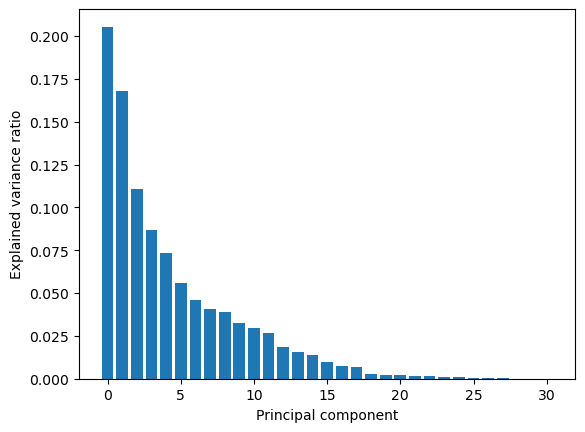

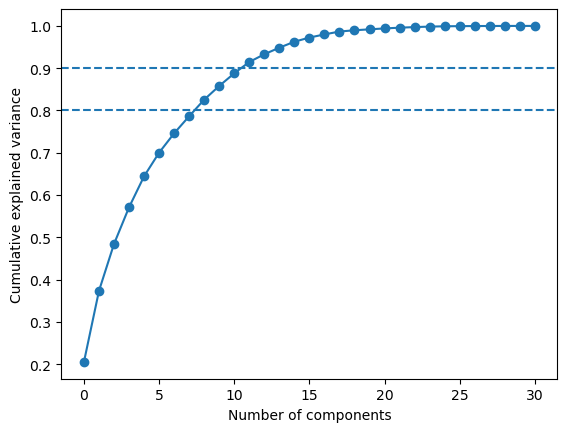

In [7]:
plot_explained_variance(pca_full)
plot_cumulative_variance(pca_full)

In [8]:
# ---- PCA final
pca, Z = fit_pca(X_scaled, n_components=10)

# ---- Loadings
loadings = pca_loadings(pca, feature_names, sort_by="PC1")
loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
energy_sum_log10,0.342551,0.148481,-0.065748,0.015908,0.105386,-0.125978,-0.052642,0.028715,-0.050295,0.053432
mag_max,0.316870,0.193414,-0.048457,0.017347,0.099424,-0.140047,-0.098895,0.092541,-0.080393,0.085928
spread_km_max,0.304302,-0.231301,0.016678,-0.067306,-0.033053,0.051359,0.148410,-0.057541,-0.016318,-0.141892
spread_km_p95,0.298107,-0.238554,0.057237,-0.076298,-0.052440,0.077258,0.142251,-0.026641,-0.054205,-0.144044
spread_km_std,0.268588,-0.195082,-0.052880,-0.033406,0.003458,0.035736,0.249375,0.112429,0.089688,-0.190039


## **5. Clusterização com KMeans**

Aplicamos o algoritmo K-Means sobre a representação reduzida via PCA para identificar regimes estatísticos recorrentes do sistema.O número de clusters $K$ é selecionado com base na análise conjunta da inércia (elbow method) e do coeficiente de silhueta, buscando um compromisso entre separação dos grupos e parcimônia do modelo.

(<Figure size 700x400 with 2 Axes>,
 (<Axes: title={'center': 'Elbow (Inertia) + Silhouette vs k'}, xlabel='k', ylabel='Inertia'>,
  <Axes: ylabel='Silhouette score'>))

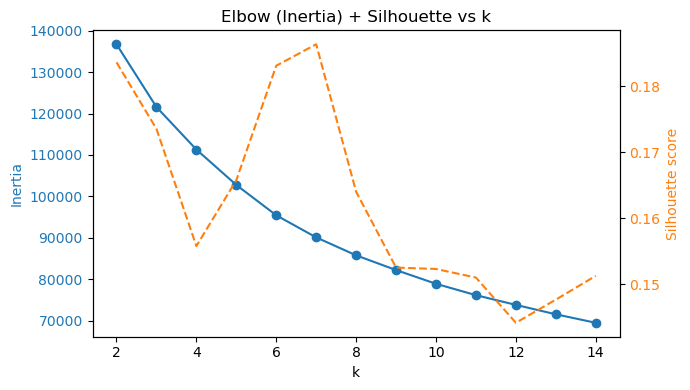

In [9]:
# ---- escolher k
plot_inertia_silhouette_vs_k(Z, ks=range(2, 15))

In [10]:
# ---- KMeans final
km = KMeans(n_clusters=2, n_init=20, random_state=42)
labels = km.fit_predict(Z)


(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Cluster centroids in PCA space'}, xlabel='PC1', ylabel='PC2'>)

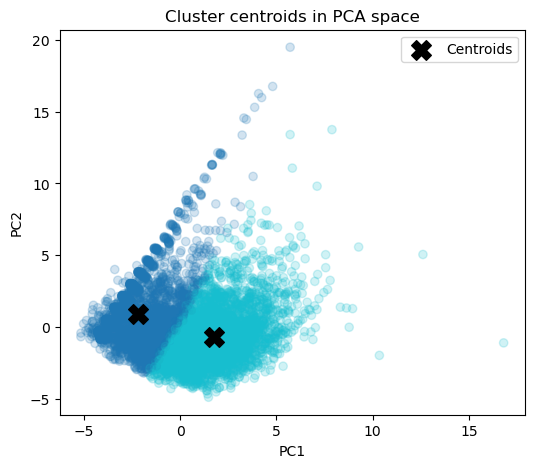

In [11]:
# ---- scatter PC1 vs PC2
plot_clusters_pca(Z, labels)

In [12]:
sil_stats = silhouette_by_cluster(Z, labels)
sil_stats

,mean,median,std,count
cluster,,,,
0,0.187995,0.195092,0.109185,2784
1,0.180060,0.185147,0.093822,3406


### **5.1 Rótulos dos clusters e macroestados**

Cada janela temporal e associada a um rótulo de um cluster obtido via K-Means no espaço reduzido PCA. Esse rótulo define o macroestado discreto do sistema

\begin{equation}
S(t) = g(X(t)),
\end{equation}

que será utilizado para análise posterior da dinâmica via cadeias de Markov.

In [13]:
# ---- Macroestado S(t) = g(X(t)) ----
# X(t) = vetor de observáveis (features) extraídas do microestado ω_t (eventos na janela)
# S(t) = cluster label (macroestado discreto)
features_df["cluster"] = labels
features_df["cluster"].value_counts().sort_index()


cluster
0    2784
1    3406
Name: count, dtype: int64

## **6. Significado geofísico dos clusters**

A interpretação dos clusters é realizada utilizando as features originais agregadas por janela em `features_df`, de modo que todas as quantidades permaneçam expressas em unidades físicas (magnitude, km, segundos, eventos/dia).
Os procedimentos de padronização e imputação são aplicados exclusivamente à matriz de features utilizada nas etapas de **PCA** e **K-Means**.

A tabela a seguir apresenta a média e o desvio padrão de um conjunto selecionado de features por cluster, permitindo caracterizar regimes sísmicos distintos em termos de intensidade (magnitude, energia liberada e taxa de eventos), extensão espacial (dispersão dos eventos) e organização temporal (intervalos entre eventos).

In [14]:
cols_phys = [
    'mag_mean',
    'mag_std',
    'depth_mean',
    'rate_per_day',
    'spread_km_mean',
    'spread_km_p95',
    'dt_mean_norm',
    'dt_p95_norm', 
    'energy_sum_log10'
]
features_df['cluster'] = labels

phys_summary = features_df.groupby('cluster')[cols_phys].agg(['mean','std']).round(3)
phys_summary

mag_mean        mag_std        depth_mean         rate_per_day  \
            mean    std    mean    std       mean     std         mean   
cluster                                                                  
0          4.746  0.251   0.190  0.166     68.955  97.954       12.694   
1          4.828  0.203   0.325  0.220     64.272  62.016       29.491   

                spread_km_mean           spread_km_p95           dt_mean_norm  \
            std           mean       std          mean       std         mean   
cluster                                                                         
0         8.849       1766.998  2005.595      2083.494  2274.781        0.296   
1        28.712       5673.007  1811.973      9467.804  3243.976        0.191   

               dt_p95_norm        energy_sum_log10         
           std        mean    std             mean    std  
cluster                                                    
0        0.213       0.347  0.213            7.427  0.489  
1        0.116       0.318  0.160            8.152  0.675

Esses resultados indicam que os clusters capturam diferenças quantitativas robustas entre regimes sísmicos distintos. Na sequência, aprofundamos essa caracterização por meio da análise espacial dos clusters, explorando de forma complementar evidências qualitativas e quantitativas associadas à sua distribuição geográfica.

### **6.1 Validação adicional via Random Forest**

Como etapa adicional de validação do significado físico dos clusters, treinamos um classificador Random Forest para predizer o rótulo de cluster a partir das features originais agregadas por janela.
Como os rótulos do K-Means são sintéticos e resultam de um procedimento não supervisionado, o modelo não é utilizado para inferência preditiva, mas sim como uma ferramenta interpretativa, com o objetivo de quantificar **quais variáveis físicas mais fortemente distinguem os regimes sísmicos** identificados.


In [15]:
X_imp = features_df[cols_phys].replace([np.inf,-np.inf], np.nan).fillna(features_df[cols_phys].median())
y_imp = features_df['cluster']

rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_imp, y_imp)

imp = pd.Series(rf.feature_importances_, index=cols_phys).sort_values(ascending=False)
imp.round(3)

spread_km_p95       0.376
spread_km_mean      0.225
rate_per_day        0.124
energy_sum_log10    0.114
mag_std             0.060
dt_mean_norm        0.033
depth_mean          0.023
mag_mean            0.022
dt_p95_norm         0.022
dtype: float64

As importâncias das features indicam que a **dispersão espacial** dos eventos é o principal fator responsável pela separação entre os regimes sísmicos, seguida pela **taxa de eventos** e pela **energia total liberada**. Estatísticas de **magnitude** contribuem de forma secundária, sobretudo por meio de sua variabilidade, enquanto a **profundidade** e a **organização temporal** dos eventos desempenham papéis claramente menores.
Essa hierarquia é consistente com as cargas do PCA e com a interpretação baseada nos centróides, reforçando a coerência geofísica dos clusters obtidos.

## **7. Dinâmica temporal de regimes: cadeia de Markov**

### **7.1 A clusterização identifica regimes físicos distintos?**

In [ ]:
# Verifica as médias das features vitais por cluster
summary = features_df.groupby('cluster')[['rate_per_day', 'energy_sum_log10', 'mag_max', 'spread_km_mean']].mean()
print(summary)

# Verifica a contagem (qual estado é mais frequente?)
counts = features_df['cluster'].value_counts()
print("\nContagem de Janelas por Cluster:")
print(counts)

         rate_per_day  energy_sum_log10   mag_max  spread_km_mean
cluster                                                          
0           12.693966          7.426856  4.854736     1766.998395
1           29.490898          8.152039  5.271996     5673.007382

Contagem de Janelas por Cluster:
cluster
1    3406
0    2784
Name: count, dtype: int64


Os resultados apresentados indicam evidências consistentes de que os dois clusters correspondem a regimes sísmicos fisicamente distintos. O cluster 0 está associado a um regime de baixa energia, caracterizado por menores taxas de eventos, menores magnitudes máximas e menor energia total liberada, sendo compatível com um comportamento de background sísmico. Em contraste, o cluster 1 apresenta taxas de eventos mais elevadas, maiores magnitudes e maior energia acumulada, caracterizando um regime mais ativo e energeticamente intenso. Essa distinção fornece uma base física clara para a análise subsequente da dinâmica temporal entre os regimes.

### **7.2 Dinâmica Markoviana dos macroestados**  

Havendo evidências de regimes sísmicos fisicamente distintos, formalizamos agora a dinâmica temporal entre esses regimes por meio de cadeias de Markov.

Cada linha do `features_df` representa vetores de features. São estatísticas agregadas (médias, quantis, energia, etc) calculadas sobre o conjunto de eventos brutos contidos na janela temporal de escolha

\begin{equation}
X(t) = \Phi(\omega_t), 
\end{equation}

onde $\Phi(.)$ é o operador coarse-graining que mapeia os eventos brutos
contidos na janela temporal em um vetor de observáveis.


Um macroestado é então definido como o rótulo do cluster associado a $X(t)$,
formalmente

\begin{equation}
S(t) = g(X(t)) \in \{0, 1, 2, ... , K - 1\}.
\end{equation}

Assim, cada ponto plotado no mapa mundi carrega duas informações:

- **Cor**: macroestado $S(t)$  

- **Posição**: componentes espaciais do vetor de observáveis $X(t)$

---
**Pergunta: Dada uma janela de eventos classificada no cluster $i$, qual a probabilidade da próxima janela transicionar para o cluster $j$?**

**Modelagem:** A dinâmica entre clusters é modelada por meio de uma cadeia de Markov,
utilizando a forma discreta da equação de Chapman–Kolmogorov. A matriz de transição é
definida como

\begin{equation}
T_{ij}=P(S_{t+1}=j|S_t=i)
\end{equation}

In [38]:
# --- Série temporal de macroestados S(t) ---
df_S = (
    features_df
    .dropna(subset=["window_start", "cluster"])
    .sort_values("window_start")
    .copy()
)

# Cria pares (S_t, S_t+1)
df_S["next_cluster"] = df_S["cluster"].shift(-1)
df_S = df_S.dropna(subset=["next_cluster"])
df_S["next_cluster"] = df_S["next_cluster"].astype(int)
df_S["cluster"] = df_S["cluster"].astype(int)

K = int(df_S["cluster"].nunique())


In [37]:
# --- Contagens de transições i -> j ---
counts = pd.crosstab(df_S["cluster"], df_S["next_cluster"])
counts

next_cluster,0,1
cluster,,
0,1304,1479
1,1480,1926


- **1304: 0 $\rightarrow$ 0 (permanência no cluster 0)**
- **1479: 0 $\rightarrow$ 1**
- **1480: 1 $\rightarrow$ 0**
- **1926: 1 $\rightarrow$ 1 (permanência no cluster 1)**

In [ ]:
# garantir matriz KxK (mesmo se algum estado não aparecer em alguma coluna/linha)
idx = pd.Index(range(K), name="i")
col = pd.Index(range(K), name="j")
counts = counts.reindex(index=idx, columns=col, fill_value=0)

- **Matriz de transição**

A estimativa empírica da matriz de transição é dada por
\begin{equation}
T_{ij}
= \frac{N_{ij}}{\sum\limits_{j'} N_{ij'}},
\end{equation}
onde $N_{ij}$ representa o número de vezes em que o sistema foi observado no macroestado $i$
e, na janela temporal seguinte, no macroestado $j$.
O denominador corresponde ao número total de transições observadas a partir do estado $i$.

Por exemplo, para a linha $i=0$,
\begin{equation}
T_{00} = \frac{1920}{1920 + 935},
\qquad
T_{01} = \frac{935}{1920 + 935}.
\end{equation}

Cada linha da matriz $T$ soma 1 e representa a distribuição de probabilidade condicional
$\mathbb{P}(S_{t+1}=j \mid S_t=i)$.


In [39]:
# --- Matriz de transição T_ij = P(S_{t+1}=j | S_t=i) ---
T = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

display(counts) 
display(T)

next_cluster,0,1
cluster,,
0,1304,1479
1,1480,1926


next_cluster,0,1
cluster,,
0,0.468559,0.531441
1,0.434527,0.565473


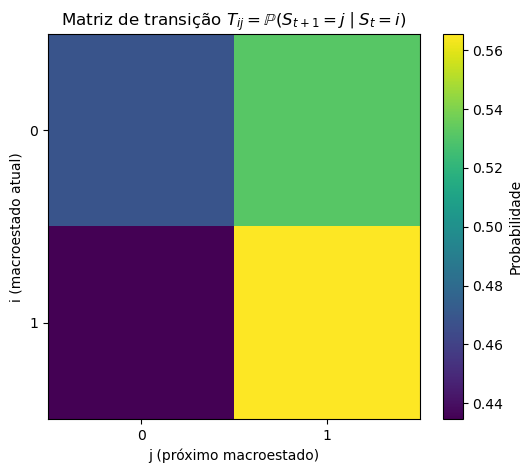

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(T.values, aspect="auto")

ax.set_title(r"Matriz de transição $T_{ij}=\mathbb{P}(S_{t+1}=j\mid S_t=i)$")
ax.set_xlabel("j (próximo macroestado)")
ax.set_ylabel("i (macroestado atual)")
ax.set_xticks(range(K))
ax.set_yticks(range(K))

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probabilidade")

plt.show()

### **7.3 Interpretação física da matriz de transição**

A matriz de transição fornece uma interpretação clara da dinâmica temporal entre os regimes sísmicos identificados.

O elemento diagonal $T_{11}$ indica que o $\textbf{cluster 1}$, associado a janelas de maior taxa sísmica e maior liberação de energia, apresenta $\textbf{alta persistência temporal}$. Uma vez que o sistema se encontra nesse regime ativo, a probabilidade de permanecer nele na janela subsequente é elevada, caracterizando-o como o $\textbf{regime dominante da dinâmica sísmica global}$.

Em contraste, o elemento $T_{00}$ revela que o $\textbf{cluster 0}$, associado a um regime de menor atividade (background sísmico), possui $\textbf{menor estabilidade temporal}$. Embora períodos de atividade reduzida ocorram, eles tendem a ser transitórios, com maior probabilidade de transição para o regime ativo.

Os termos fora da diagonal, $T_{01}$ e $T_{10}$, reforçam essa assimetria dinâmica. Em particular, a probabilidade $T_{01}$ indica que estados de baixa atividade tendem a ser rapidamente interrompidos por episódios mais energéticos, enquanto $T_{10}$ mostra que a transição inversa é menos frequente. Esse comportamento sugere que o sistema sísmico global está continuamente sujeito a perturbações que o afastam do regime calmo.

Em conjunto, esses resultados indicam que a sismicidade global pode ser descrita como um $\textbf{processo de relaxamento contínuo e metastável}$, no qual intervalos de menor atividade emergem temporariamente, mas são rapidamente superados pela dinâmica dominante de liberação de energia associada às interações tectônicas de larga escala.


## **8. Validação espacial dos regimes dinâmicos**

### **8.1 Validação qualitativa**

In [17]:
from src.spatial_validation.plots import (
    make_time_gate,
    prepare_spatial_frames,
    load_plates_geojson,
    plot_clusters_with_plates,
)

YEAR, MONTH, N_MONTHS = 2024, 6, 6
minmag = 4.5

start, end = make_time_gate(year=YEAR, month=MONTH, n_months=N_MONTHS)
tmp, ev = prepare_spatial_frames(features_df=features_df, df=df, start=start, end=end, minmag=minmag)
plates_geojson = load_plates_geojson()

fig = plot_clusters_with_plates(tmp=tmp, ev=ev, plates_geojson=plates_geojson, start=start, end=end, minmag=minmag)
fig.show()

# salva figura html interativa
reports_dir = Path("../reports")
reports_dir.mkdir(exist_ok=True)

outpath = reports_dir / "clusters_map_mag4p5_2024_06_6m.html"
fig.write_html(outpath)


Os pontos pequenos representam os eventos sísmicos reais ($M \ge 4.5$), coloridos de acordo com o regime dinâmico (cluster) identificado pelo modelo de clusterização na janela temporal correspondente. As linhas pretas indicam as fronteiras de placas tectônicas.

A análise visual-qualitativa revela que o Regime Crítico (Cluster 1) não é homogêneo, mas apresenta **âncoras geofísicas bem definidas**. Por exemplo, na **zona de subducção da Placa de Nazca**, localizada ao longo da costa oeste da América do Sul, existe uma predominância observável do Cluster 1 nessa região, associada a elevados níveis de liberação energética. Isso sugere que essa zona pode atuar (ou ter atuado dentro do escopo dos dados) como um ''motor'' do sistema sísmico global: eventos de grande magnitude nessa região são, por si só, suficientes para caracterizar uma janela temporal como crítica.

Além disso, o restante do **Círculo de Fogo do Pacífico** contribui para o Regime Crítico de forma coletiva. O Cluster 1 captura momentos em que múltiplas falhas do Pacífico entram em atividade quase simultaneamente, reforçando a interpretação de que o regime de alta energia é um **fenômeno sistêmico e conectado**, e não apenas o resultado de eventos isolados.

### **8.2 Validação quantitativa**

,count,mean_km,median_km,std_km,q25_km,q75_km,p90_km
cluster,,,,,,,
0,503,887.470179,430.259328,1391.107887,167.618916,957.911771,1876.285306
1,493,1520.307684,874.680346,1894.270388,338.659595,2017.996959,3589.657896


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Centroid distance to nearest plate boundary (km)'}, xlabel='Cluster', ylabel='Distance to plate (km)'>)

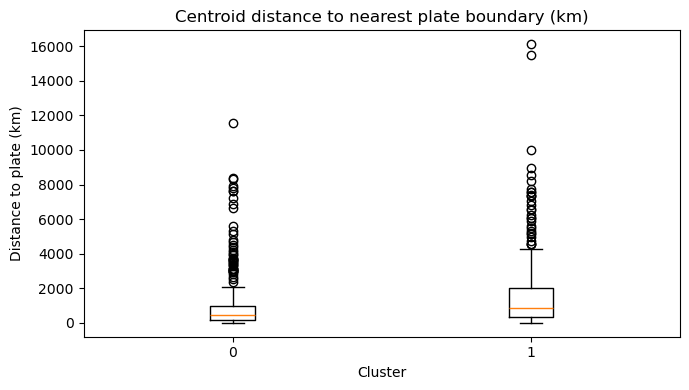

In [18]:
tmp_dist = add_plate_distance_column(tmp, plates_geojson)
summary = summarize_plate_distance_by_cluster(tmp_dist)
display(summary)

plot_distance_boxplot(tmp_dist)


Os box-plots da distância dos centróides às fronteiras de placas tectônicas exibem, à primeira vista, um resultado contraintuitivo: o **Cluster 1 (Crítico/Ativo)** apresenta uma **mediana de distância maior** às bordas das placas do que o **Cluster 0 (Basal/Calmo)**. Esse resultado **não implica** que o regime crítico seja predominantemente intraplaca (mais longe dos seus limites ativos). Pelo contrário, ele reflete a **natureza espacialmente dispersa** desse regime. Enquanto o Cluster 0 corresponde a janelas dominadas por sismicidade local - nas quais os eventos se concentram ao redor de uma única falha ativa e o centróide geométrico coincide aproximadamente com a fronteira tectônica - o Cluster 1 representa janelas caracterizadas por **sincronização temporal de eventos geograficamente distantes**.

Em janelas críticas, é comum a ocorrência quase simultânea de sismos em regiões distintas do globo (por exemplo, no Círculo de Fogo do Pacífico e nos Himalaias). Nesses casos, o centróide esférico atua como um ''centro de massa'' geométrico do conjunto de eventos, deslocando-se frequentemente para regiões oceânicas ou continentais pouco ativas. Esse efeito aumenta artificialmente a distância média às placas, mas é consistente com os altos valores de dispersão espacial (spread) observados nas features do Cluster 1.

## **9. Síntese dinâmica-espacial**

Em conjunto com a **matriz de transição de Markov**, a análise espacial completa o ciclo de validação do modelo.

A **metaestabilidade do Cluster 1**, evidenciada pela alta probabilidade de transições \(1 $\rightarrow 1\$), é sustentada pela existência de múltiplos centros sísmicos ativos (Nazca, Japão, Indonésia, entre outros), que atuam de forma alternada ou simultânea para manter o nível global de energia elevado.

Por outro lado, o sistema raramente atinge o estado basal (Cluster 0), pois a probabilidade de silêncio simultâneo em todas essas zonas ativas é estatisticamente baixa. Assim, o **estado calmo emerge como uma anomalia transitória**, enquanto o ''barulho'' sísmico global representa o estado operacional fundamental do sistema terrestre.


## **10. Perspectivas futuras e próximos passos**

A validação física e espacial do modelo de regimes dinâmicos abre caminho para investigações mais profundas sobre a estabilidade e a universalidade da abordagem proposta. Os próximos passos concentram-se em três eixos principais:

**1. Análise de Sensibilidade e Robustez Paramétrica**:
O estudo atual fixou a janela temporal ($\Delta t$) em um intervalo discreto sem sobreposição, garantindo estados de transição não espúrios na cadeia de Markov. Investigações futuras devem submeter o modelo a testes de estresse variando a granulação temporal (ex: janelas de 6h, 12h, 24h) e introduzindo janelas deslizantes com sobreposição (rolling windows). O objetivo é verificar a invariância dos clusters identificados e da Matriz de Transição. Um regime físico robusto deve persistir independentemente de pequenas variações nos hiperparâmetros de extração, garantindo que os estados (Basal vs. Crítico) não sejam artefatos da discretização escolhida.

**2.Formalização como Sistema de Dois Níveis (TLS)**: Dada a clara distinção binária observada (Repouso vs. Atividade), propõe-se aprofundar o tratamento teórico do fenômeno como um Sistema de Dois Níveis (Two-Level System), análogo a modelos de física estatística. Isso envolve analisar a distribuição dos tempos de residência (waiting times) em cada estado. Verificar se esses tempos seguem uma distribuição exponencial (processo de Poisson) ou leis de potência permitirá classificar a sismicidade global não apenas como uma cadeia de Markov, mas como um sistema físico com memória ou criticalidade auto-organizada (SOC).

**3. Generalização para Outros Sistemas Estocásticos**: A metodologia desenvolvida (Feature Engineering temporal seguida de Clustering não supervisionado e validação via Markov)  possui potencial de aplicação universal em séries temporais não estacionárias. Pretende-se expandir a aplicação para domínios fora da sismologia, tais como:

- **Climatologia:** Identificação de regimes de estabilidade vs. eventos extremos em dados de precipitação e temperatura.

- **Ativos Financeiros:** Detecção de regimes de volatilidade em ativos de alta frequência, onde "calmaria" e "crise" alternam-se de forma estocástica similar aos terremotos.

Essa agenda de pesquisa visa transformar o modelo atual de uma ferramenta de diagnóstico sísmico para um framework generalizável de detecção de fases em sistemas complexos